## 1. Protein Structural Change Data Base (PSCDB)

The [Protein Structural Change DataBase](https://academic.oup.com/nar/article/40/D1/D554/2903618) provides information about the structural changes observed in proteins upon ligand binding. The protein structural changes were classified into seven classes: 
1. Coupled Domain Motion (N=59)
2. Independent Domain Motion (N=70)
3. Coupled Local Motion (N=125)
4. Independent Local Motion (N=135)
5. Burying Ligand Motion (N=104)
6. No significant motion (N=311)
7. Other types (N=35)

The following image illustrates the different classes of structural changes:
![Protein Structural Change Classes](./image/pscdb_7.jpg)


Take time to understand the database. Run the following cell to load the data and explore its structure. 

In [1]:
# Downloading the data for the GNN class if you are not using DelftBlue. Uncomment the next two lines
#!git clone https://github.com/courtel/GNN_dl_workshop.git gnn_data

# Point this to the appropriate gnn_data folder
GNN_DATA_FOLDER = "./gnn_data/" 

In [2]:
import os
import pandas as pd

pscdb_csv_path = os.path.join(GNN_DATA_FOLDER, "df_pscdb.csv")

df_pscdb = pd.read_csv(pscdb_csv_path)
print(df_pscdb.head())

   Unnamed: 0  level_0  index PSCID  \
0           1        1      1  CD.2   
1           4        4      4  CD.5   
2           5        5      5  CD.6   
3           6        6      6  CD.7   
4           8        8      8  CD.9   

                                   Protein Name Free form Bound form  Ligands  \
0                              ADENYLATE KINASE    4ake_A     2eck_A  ADP,AMP   
1                           ELONGATION FACTOR 2    1n0v_D     1n0u_A      SO1   
2                              CITRATE SYNTHASE   5csc_AB    6cts_AA    2xCIC   
3                  ARACHIDONATE 15-LIPOXYGENASE    2p0m_A     2p0m_B      RS7   
4  3-PHOSPHOSHIKIMATE 1-CARBOXYVINYLTRANSFERASE    2bjb_A     2o0d_A      S3P   

   Classification(?)            motion_type free_pdb Free Chains Bound PDB  \
0             200003  coupled_domain_motion     4ake           A      2eck   
1             110002  coupled_domain_motion     1n0v           D      1n0u   
2             102001  coupled_domain_motion 

The important columns for us are: 
- free_pdb: it gives us the unique accession code for the structure deposited in the Protein Data Bank (PDB ID)
- motion_type: this is the class label for the structural change observed in the protein upon ligand binding. 




## 2. Data pre-processing

The steps that we need to take to pre-process the data are as follows:
### 2a) Convert class labels into numbers and map it to the pdb string

In [3]:
mapping_pdb_to_motion_type = {x["free_pdb"]:x["motion_type"] for _, x in df_pscdb.iterrows()}


In [4]:
from src.utils import show_random_elements_in_dictionary
show_random_elements_in_dictionary(mapping_pdb_to_motion_type, 10)

Key: 1hka, Value: independent_local_motion
Key: 1t2w, Value: coupled_local_motion
Key: 2oam, Value: burying_ligand_motion
Key: 1dcd, Value: burying_ligand_motion
Key: 1t7n, Value: no_significant_motion
Key: 2gp7, Value: coupled_local_motion
Key: 1vsm, Value: independent_local_motion
Key: 3b9n, Value: no_significant_motion
Key: 1xxo, Value: coupled_local_motion
Key: 1obs, Value: no_significant_motion


For this task, we can restrict ourselves to domain motions as they can be easily captured using residue-level abstractions. We will only consider "independent_domain_motion", "coupled_domain_motion", and "no_significant_motion" classes.

In [5]:
included_motion_types = ["independent_domain_motion", "independent_local_motion", "no_significant_motion"]
filtered_mapping_pdb_to_motion_type = {
                                    k:v for k,v in mapping_pdb_to_motion_type.items()\
                                    if v in included_motion_types
                                }

original_num_samples = len(mapping_pdb_to_motion_type)
filtered_num_samples = len(filtered_mapping_pdb_to_motion_type)
print(f"Original number of samples: {original_num_samples}")
print(f"Filtered number of samples: {filtered_num_samples}")
print(f"Random samples from the filtered mapping:")
show_random_elements_in_dictionary(filtered_mapping_pdb_to_motion_type, 10)

Original number of samples: 517
Filtered number of samples: 329
Random samples from the filtered mapping:
Key: 2d2q, Value: no_significant_motion
Key: 3crm, Value: no_significant_motion
Key: 1ebb, Value: no_significant_motion
Key: 4ptd, Value: no_significant_motion
Key: 3c95, Value: independent_local_motion
Key: 1e0d, Value: independent_domain_motion
Key: 2idh, Value: no_significant_motion
Key: 1gnu, Value: no_significant_motion
Key: 2hkn, Value: no_significant_motion
Key: 1uyp, Value: no_significant_motion


### 2b) Convert motion type into integer strings


In [38]:
motion_type_to_integer = {x : i for i, x in enumerate(set(filtered_mapping_pdb_to_motion_type.values()))}
for k, v in motion_type_to_integer.items():
    count = sum(1 for motion_type in filtered_mapping_pdb_to_motion_type.values() if motion_type == k)
    print(f"{k} : {v} (count: {count})")

pdb_id_to_integer_label = {k: motion_type_to_integer[v] for k, v in filtered_mapping_pdb_to_motion_type.items()}
print(f"Random samples from the pdb_id to integer label mapping:")
show_random_elements_in_dictionary(pdb_id_to_integer_label, 10)
    

independent_local_motion : 0 (count: 89)
independent_domain_motion : 1 (count: 41)
no_significant_motion : 2 (count: 199)
Random samples from the pdb_id to integer label mapping:
Key: 1bdj, Value: 2
Key: 2j3p, Value: 2
Key: 1jop, Value: 0
Key: 2gt1, Value: 1
Key: 2f5g, Value: 2
Key: 1cqz, Value: 2
Key: 2paw, Value: 2
Key: 2pgy, Value: 0
Key: 1f6y, Value: 2
Key: 1ri5, Value: 2


### 2c) Divide the data into test, train and validation sets

Use the `construct_graph` function from the first module to create a graph representation of the protein structure for each PDB ID. 

The PDB files are present in the `gnn_data` directory. The directory structure is as follows:

```
gnn_data/
├── all_datasets/
│   ├── test/
│   │   ├── 1a3h.pdb
│   │   ├── 1agj.pdb
│   │   └── ...
│   ├── train/
│   │   ├── 1a48.pdb
│   │   ├── 1ayf.pdb
│   │   └── ...
│   └── val/
│       ├── 1bs0.pdb
│       ├── 1cmb.pdb
│       └── ...
```

In [7]:
raw_pdb_files_test = [\
    f for f in os.listdir(os.path.join(GNN_DATA_FOLDER, "all_datasets", "test"))\
        if f.endswith(".pdb")
]
raw_pdb_files_train = [\
    f for f in os.listdir(os.path.join(GNN_DATA_FOLDER, "all_datasets", "train"))\
        if f.endswith(".pdb")
]
raw_pdb_files_val = [\
    f for f in os.listdir(os.path.join(GNN_DATA_FOLDER, "all_datasets", "val"))\
        if f.endswith(".pdb")
]

## Curate the raw PDB files to only include those that are in the filtered mapping
pdb_files_test = [f for f in raw_pdb_files_test if f[:-4] in filtered_mapping_pdb_to_motion_type]
pdb_files_train = [f for f in raw_pdb_files_train if f[:-4] in filtered_mapping_pdb_to_motion_type]
pdb_files_val = [f for f in raw_pdb_files_val if f[:-4] in filtered_mapping_pdb_to_motion_type]

# Convert the pdb paths to full paths
pdb_files_test = [os.path.join(GNN_DATA_FOLDER, "all_datasets", "test", f) for f in pdb_files_test]
pdb_files_train = [os.path.join(GNN_DATA_FOLDER, "all_datasets", "train", f) for f in pdb_files_train]
pdb_files_val = [os.path.join(GNN_DATA_FOLDER, "all_datasets", "val", f) for f in pdb_files_val]

print(f"Number of raw PDB files in test set: {len(pdb_files_test)}")
print(f"Number of raw PDB files in train set: {len(pdb_files_train)}")
print(f"Number of raw PDB files in val set: {len(pdb_files_val)}")

Number of raw PDB files in test set: 66
Number of raw PDB files in train set: 210
Number of raw PDB files in val set: 53


It is a good time to check how the classes are balanced between the train, test, and validation sets. 

In [8]:
# Check the distribution of motion types in the filtered dataset between the train, test, and val sets
def count_motion_types_in_pdb_files(pdb_files, mapping_pdb_to_motion_type):
    motion_type_counts = {motion_type: 0 for motion_type in set(mapping_pdb_to_motion_type.values())}
    for pdb_file in pdb_files:
        pdb_id = os.path.basename(pdb_file)[:-4]  # Remove the .pdb extension
        if pdb_id in mapping_pdb_to_motion_type:
            motion_type = mapping_pdb_to_motion_type[pdb_id]
            motion_type_counts[motion_type] += 1
    motion_type_counts["total"] = sum(motion_type_counts.values())
    return motion_type_counts



test_motion_type_counts = count_motion_types_in_pdb_files(
    pdb_files_test, filtered_mapping_pdb_to_motion_type
)
train_motion_type_counts = count_motion_types_in_pdb_files(
    pdb_files_train, filtered_mapping_pdb_to_motion_type
)
val_motion_type_counts = count_motion_types_in_pdb_files(
    pdb_files_val, filtered_mapping_pdb_to_motion_type
)
print("Motion type distribution in test set:")
for motion_type, count in test_motion_type_counts.items():
    print(f"{motion_type}: {count} : {count/test_motion_type_counts['total']:.2%}")
print("\nMotion type distribution in train set:")
for motion_type, count in train_motion_type_counts.items():
    print(f"{motion_type}: {count} : {count/train_motion_type_counts['total']:.2%}")
print("\nMotion type distribution in val set:")
for motion_type, count in val_motion_type_counts.items():
    print(f"{motion_type}: {count} : {count/val_motion_type_counts['total']:.2%}")



Motion type distribution in test set:
independent_local_motion: 18 : 27.27%
independent_domain_motion: 8 : 12.12%
no_significant_motion: 40 : 60.61%
total: 66 : 100.00%

Motion type distribution in train set:
independent_local_motion: 57 : 27.14%
independent_domain_motion: 26 : 12.38%
no_significant_motion: 127 : 60.48%
total: 210 : 100.00%

Motion type distribution in val set:
independent_local_motion: 14 : 26.42%
independent_domain_motion: 7 : 13.21%
no_significant_motion: 32 : 60.38%
total: 53 : 100.00%


### 2d) Creating protein_graph for each pdb id in the filtered dataset

We need to understand how to create a graph structure for each protein. 

In [20]:
import networkx as nx
def display_graph(protein_graph):
    from plotly import graph_objects as go
    # Convert to NetworkX graph
    nx_graph = nx.Graph(protein_graph)
    pos_2d = nx.spring_layout(nx_graph, seed=0)

    # Build edge traces for the 2D graph
    edge_x, edge_y = [], []
    for edge in nx_graph.edges():
        x0, y0 = pos_2d[edge[0]]
        x1, y1 = pos_2d[edge[1]]
        edge_x.extend([x0, x1, None])
        edge_y.extend([y0, y1, None])

    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=1, color='gray'),
        hoverinfo='all',
        mode='lines'
    )

    # Build node trace for the 2D graph
    node_x = [pos_2d[node][0] for node in nx_graph.nodes()]
    node_y = [pos_2d[node][1] for node in nx_graph.nodes()]
    node_labels = list(nx_graph.nodes())

    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode='markers+text',           # was 'markers'
        text=node_labels,              # text shown next to each node
        textposition='top center',     # where the label sits relative to marker
        hovertext=node_labels,         # text shown on hover
        hoverinfo='text',
        marker=dict(size=15, color='lightblue', line=dict(width=1, color='black')),
        textfont=dict(size=8),
    )

    # Create the figure
    fig = go.Figure(data=[edge_trace, node_trace])
    fig.update_scenes(
        xaxis=dict(showgrid=False, showticklabels=False, showbackground=False, title=''),
        yaxis=dict(showgrid=False, showticklabels=False, showbackground=False, title=''),    
    )
    fig.show()
    


In [34]:
from src.utils import convert_pdb_path_to_graph, display_protein_with_graph
import graphein.protein as gp
pdb_path_example = pdb_files_train[0]
print(f"Example PDB path: {pdb_path_example}")

protein_graph_example = convert_pdb_path_to_graph(pdb_path_example, distance_threshold=6, contain_b_factor=True)
print(f"Converted PDB file into graph with {protein_graph_example.number_of_nodes()} nodes")



Example PDB path: ./gnn_data/all_datasets/train/1z9u.pdb
Converted PDB file into graph with 176 nodes


In [35]:
example_node = list(protein_graph_example.nodes())[2]
print(f"Example node: {example_node}")
example_node_attributes = protein_graph_example.nodes[example_node]
print(f"Attributes of example node:")
for attr, value in example_node_attributes.items():
    if isinstance(value, (int, float, str)):
        print(f"\t {attr}: {value}")
    else:
        print(f"\t {attr}: (type: {type(value)}, length: {len(value)})")


example_edge = list(protein_graph_example.edges())[2]
print(f"Example edge: {example_edge}")
example_edge_attributes = protein_graph_example.edges[example_edge]
print(f"Attributes of example edge:")
for attr, value in example_edge_attributes.items():
    if isinstance(value, (int, float, str)):
        print(f"\t {attr}: {value}")
    else:
        print(f"\t {attr}: (type: {type(value)}, length: {len(value)})")
        

Example node: 2
Attributes of example node:
	 x: (type: <class 'torch.Tensor'>, length: 4)
Example edge: (1, 2)
Attributes of example edge:
	 edge_attr: (type: <class 'torch.Tensor'>, length: 1)


### 2e) Convert the graph into a PyTorch Geometric Data object
We can now convert the `networkx.Graph` object into a `torch_geometric.data.Data` object, which is the standard format for graph data in PyTorch Geometric.

In [36]:
import torch
import torch.nn as nn
from torch_geometric.utils import from_networkx

tensor_graph_example = from_networkx(protein_graph_example)


Explore the tensor data structure

In [39]:
# Convert the node attributes to tensors
def convert_pdb_path_to_pytorch_tensor(pdb_path, pdb_id_to_integer_label):
    # Convert the PDB file to a graph
    protein_graph = convert_pdb_path_to_graph(pdb_path, distance_threshold=6, contain_b_factor=True)
    # Convert the graph to a PyTorch Geometric Data object
    data = from_networkx(protein_graph)

    
    # Add name
    data.name = os.path.basename(pdb_path)[:-4]  # Remove the .pdb extension

    # Add target
    data.y = pdb_id_to_integer_label[data.name]
    
    return data

In [42]:
tensor_graph_example = convert_pdb_path_to_pytorch_tensor(pdb_path_example, pdb_id_to_integer_label)
tensor_graph_example

Data(x=[176, 4], edge_index=[2, 10636], edge_attr=[10636, 1], name='1z9u', y=1)

In [45]:
from tqdm import tqdm
def get_list_of_pytorch_graphs_from_pdb_paths(pdb_paths, pdb_id_to_integer_label):
    pytorch_graphs = []
    for pdb_path in tqdm(pdb_paths, desc="Converting PDB files to PyTorch tensors"):
        pytorch_graph = convert_pdb_path_to_pytorch_tensor(pdb_path, pdb_id_to_integer_label)
        pytorch_graphs.append(pytorch_graph)
    return pytorch_graphs


In [46]:
train_pytorch_graphs = get_list_of_pytorch_graphs_from_pdb_paths(pdb_files_train, pdb_id_to_integer_label)
test_pytorch_graphs = get_list_of_pytorch_graphs_from_pdb_paths(pdb_files_test, pdb_id_to_integer_label)
val_pytorch_graphs = get_list_of_pytorch_graphs_from_pdb_paths(pdb_files_val, pdb_id_to_integer_label)
print(f"Number of PyTorch graphs in train set: {len(train_pytorch_graphs)}")
print(f"Number of PyTorch graphs in test set: {len(test_pytorch_graphs)}")
print(f"Number of PyTorch graphs in val set: {len(val_pytorch_graphs)}")


Converting PDB files to PyTorch tensors:   0%|          | 0/210 [00:00<?, ?it/s]

Converting PDB files to PyTorch tensors: 100%|██████████| 53/53 [00:24<00:00,  2.17it/s]

Number of PyTorch graphs in train set: 210
Number of PyTorch graphs in test set: 66
Number of PyTorch graphs in val set: 53


In [47]:
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool

train_dataloader = DataLoader(train_pytorch_graphs, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_pytorch_graphs, batch_size=32, shuffle=False)
val_dataloader = DataLoader(val_pytorch_graphs, batch_size=32, shuffle=False)


## 3. Training Graph Convolutional Networks 

Now that we have our data pre-processed and converted into the appropriate format, we can proceed to train a Graph Convolutional Network (GCN) for classifying the structural changes in proteins. First we define out GCN architecture. We will use a simple architecture with two graph convolutional layers followed by a fully connected layer for classification.


### 3a) Model definition

In [86]:
## Useful functions
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    total_accuracy = 0
    for data in dataloader:
        # Move data to the same device as the model
        data = data.to(device)
        # Forward pass
        out = model(data)
        # Compute loss
        loss = criterion(out, data.y)
        total_loss += loss.item() 
        num_correct = (out.argmax(dim=1) == data.y).sum().item()
        total_accuracy += num_correct 

    avg_loss = total_loss / len(dataloader)
    avg_accuracy = total_accuracy / len(dataloader.dataset)   
    return avg_loss, avg_accuracy

def make_prediction_for_pdb(pdb_path, model, pdb_id_to_integer_label, device):
    model.eval()
    data = convert_pdb_path_to_pytorch_tensor(pdb_path, pdb_id_to_integer_label)
    data = data.to(device)
    with torch.no_grad():
        out = model(data)
        predicted_label = out.argmax(dim=1).item()
    return predicted_label

def display_pdb_graph_with_prediction(pdb_path, model, pdb_id_to_integer_label, device):
    from src.utils import return_protein_graph_for_pdb_path, display_protein_with_graph
    predicted_label = make_prediction_for_pdb(pdb_path, model, pdb_id_to_integer_label, device)
    predicted_motion_type = [k for k, v in motion_type_to_integer.items() if v == predicted_label][0]
    print(f"Predicted motion type for {os.path.basename(pdb_path)}: {predicted_motion_type}")
    protein_graph = return_protein_graph_for_pdb_path(pdb_path)
    display_protein_with_graph(protein_graph)

In [87]:
class GCNGraphLevel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCNGraphLevel, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)

        x = global_max_pool(x, batch)  

        out = self.lin(x)

        return out

### 3b) Set hyperparameters

In [88]:
NUM_EPOCHS = 100
LEARNING_RATE = 0.01
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### 3c) Train the model

In [89]:
model = GCNGraphLevel(in_channels=4, hidden_channels=16, out_channels=len(motion_type_to_integer))
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = torch.nn.CrossEntropyLoss()

model.to(device)

GCNGraphLevel(
  (conv1): GCNConv(4, 16)
  (conv2): GCNConv(16, 16)
  (lin): Linear(in_features=16, out_features=3, bias=True)
)

In [76]:
train_losses = []
val_losses = []
train_accuracy = []
val_accuracy = []
print(f"Epoch \t Train Loss \t Train Accuracy \t Val Loss \t Val Accuracy")
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    for data in train_dataloader:
        # Move data to the same device as the model
        data = data.to(device)
        # Zero gradients
        optimizer.zero_grad()
        # Forward pass
        out = model(data)
        # Compute loss
        loss = criterion(out, data.y)
        # Backward pass 
        loss.backward()
        # Gradient descent 
        optimizer.step()
        # Accumulate loss
        total_loss += loss.item() 
    

    avg_train_loss, avg_train_accuracy = evaluate(model, train_dataloader, criterion, device)
    avg_val_loss, avg_val_accuracy = evaluate(model, val_dataloader, criterion, device)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracy.append(avg_train_accuracy)
    val_accuracy.append(avg_val_accuracy)

    print(f"{epoch+1}/{NUM_EPOCHS} \t {avg_train_loss:.4f} \t {avg_train_accuracy:.4f} \t {avg_val_loss:.4f} \t {avg_val_accuracy:.4f}")

Epoch 	 Train Loss 	 Train Accuracy 	 Val Loss 	 Val Accuracy
1/100 	 2.2311 	 0.4286 	 3.3442 	 0.2830
2/100 	 1.5532 	 0.5429 	 1.9000 	 0.5094
3/100 	 1.0356 	 0.4762 	 1.5006 	 0.4340
4/100 	 0.9832 	 0.5619 	 1.3327 	 0.4528
5/100 	 0.8738 	 0.5810 	 1.2781 	 0.5472
6/100 	 0.8704 	 0.6000 	 1.4620 	 0.4151
7/100 	 0.8100 	 0.6381 	 1.2616 	 0.5094
8/100 	 0.7762 	 0.6429 	 1.3341 	 0.5283
9/100 	 0.7653 	 0.6905 	 1.3269 	 0.5094
10/100 	 0.7377 	 0.6952 	 1.2520 	 0.4906
11/100 	 0.7219 	 0.6714 	 1.3002 	 0.5094
12/100 	 0.7080 	 0.7143 	 1.2648 	 0.5283
13/100 	 0.7076 	 0.7476 	 1.3151 	 0.4906
14/100 	 0.6643 	 0.7000 	 1.4033 	 0.4717
15/100 	 0.6830 	 0.6857 	 1.2684 	 0.5472
16/100 	 0.6813 	 0.7333 	 1.4281 	 0.4340
17/100 	 0.6478 	 0.7714 	 1.2865 	 0.4717
18/100 	 0.6298 	 0.7476 	 1.3533 	 0.4717
19/100 	 0.6387 	 0.7857 	 1.4418 	 0.4717
20/100 	 0.6045 	 0.7571 	 1.3251 	 0.4906
21/100 	 0.6238 	 0.7000 	 1.2509 	 0.5849
22/100 	 0.6041 	 0.7952 	 1.4829 	 0.4528
2

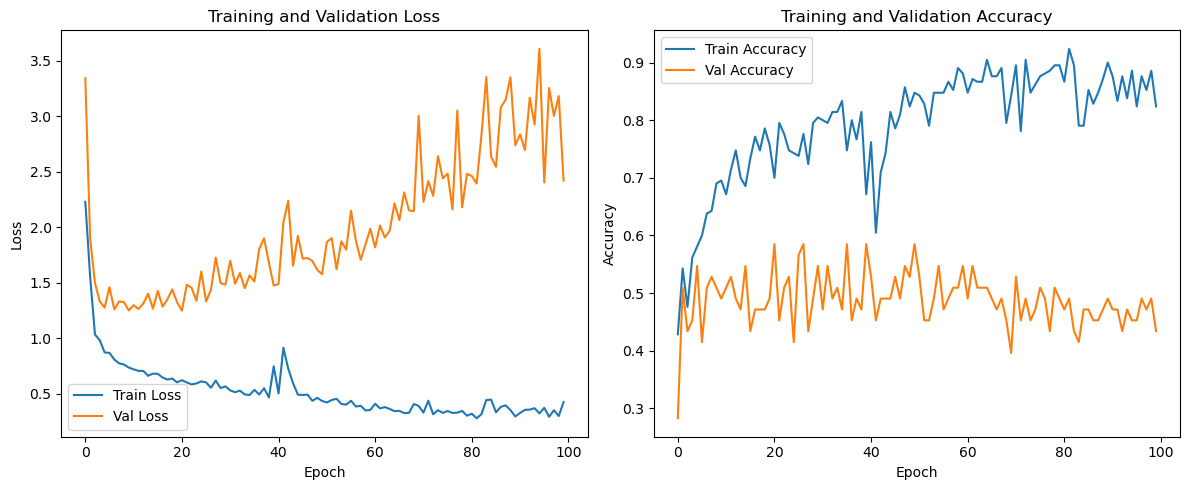

In [77]:
# Plot the training and validation loss curves
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses, label='Train Loss')
ax[0].plot(val_losses, label='Val Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Training and Validation Loss')
ax[0].legend()
ax[1].plot(train_accuracy, label='Train Accuracy')
ax[1].plot(val_accuracy, label='Val Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Training and Validation Accuracy')
ax[1].legend()
plt.tight_layout()
plt.show()

## 4. Evaluating the model

In [90]:
# Evaluate the model on the test set
_, test_accuracy = evaluate(model, test_dataloader, criterion, device)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")


Test Accuracy: 30.30%


In [85]:
test_pdb_path = pdb_files_test[1]
true_label = pdb_id_to_integer_label[os.path.basename(test_pdb_path)[:-4]]
true_motion_type = [k for k, v in motion_type_to_integer.items() if v == true_label][0]
print(f"True motion type for {os.path.basename(test_pdb_path)}: {true_motion_type}")
display_pdb_graph_with_prediction(test_pdb_path, model, pdb_id_to_integer_label, device)

True motion type for 1qim.pdb: no_significant_motion


Output()

Predicted motion type for 1qim.pdb: independent_local_motion


With 3 predicted classes, a random baseline accuracy would be around 33.3%. Did your model perform better than that? 

Can you think of any ways to improve the model's performance?